In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter("ignore", pd.errors.DtypeWarning)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import dcor
import math
from glob import glob
import os
import ruptures as rpt
from scipy.stats import pearsonr
from ydata_profiling import ProfileReport
from helper_functions import (
    load_signal_data,
    extract_operating_periods,
    find_pelt_change_points,
    extract_steady_states,
    test_dbscan_eps
)

In [4]:
# Load raw data
dfs_raw = load_signal_data(search_folder="RawMeasurements/2024-06-01_2024-10-31/G2_relevant")

In [5]:
# Adjust the unit for plotting
def clean_unit(unit):
    if pd.isna(unit):
        return "Value"
    return str(unit).split(":")[-1]

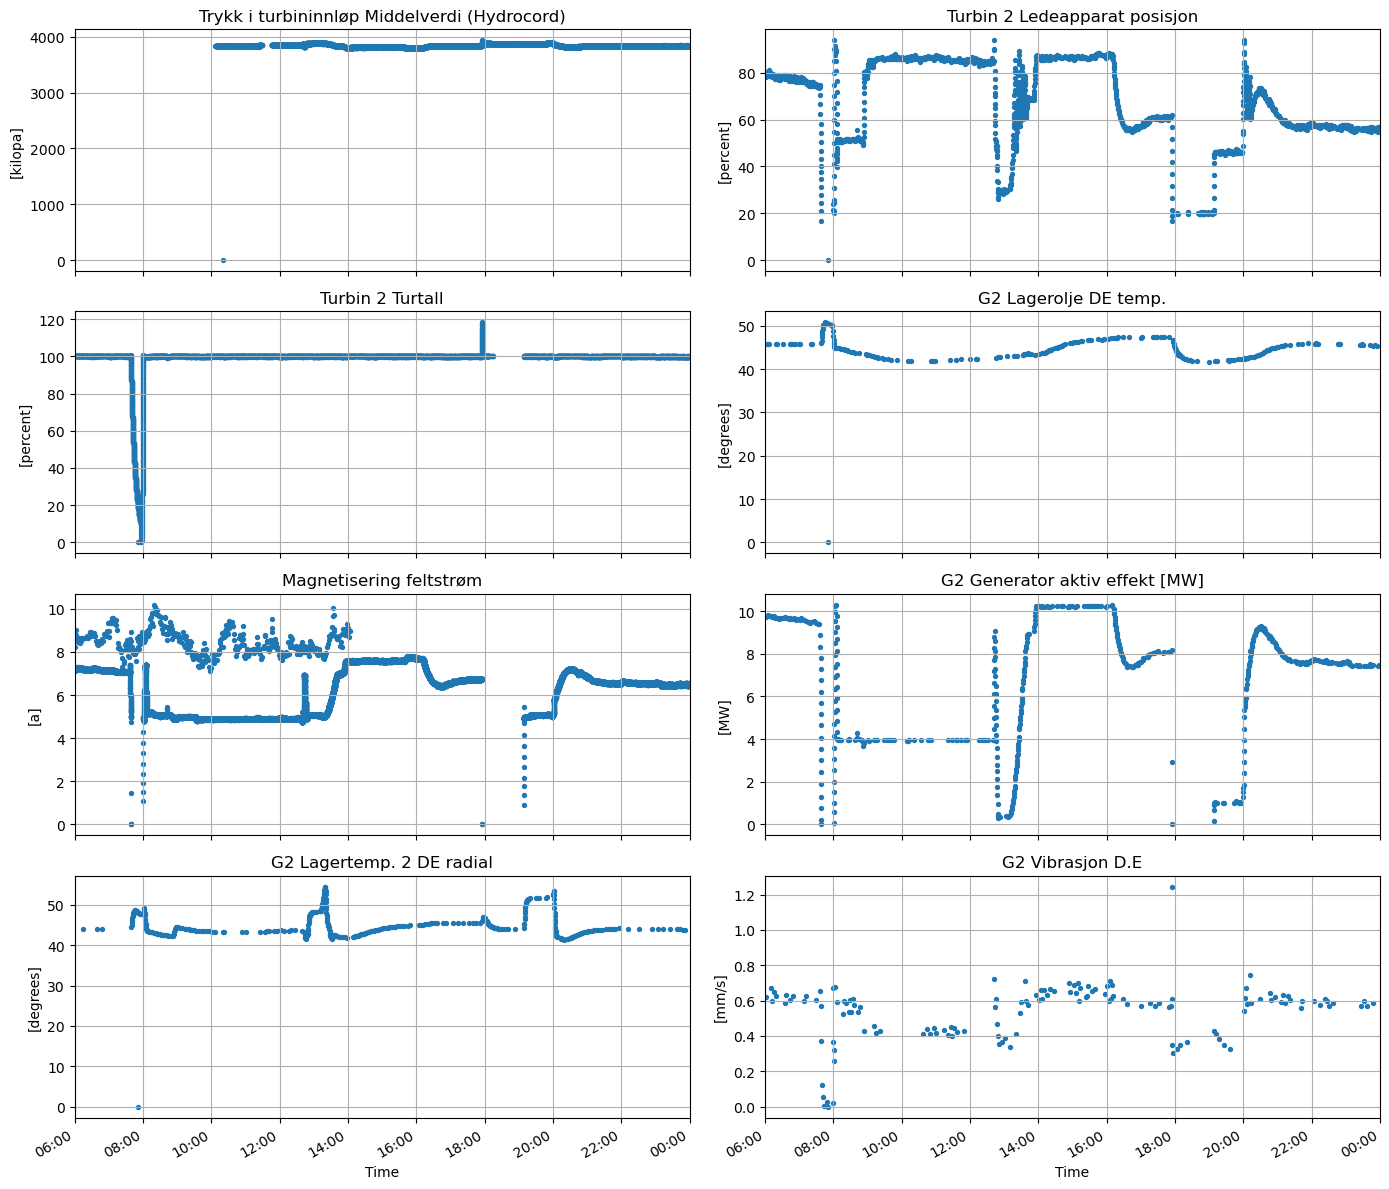

In [6]:
start_time = pd.Timestamp("2024-06-03 06:00:00")
end_time = start_time + pd.Timedelta(hours=18)

n_plots = len(dfs_raw)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), sharex=True)
axes = axes.flatten()

for i in range(n_plots):
    row = dfs_raw.loc[i]

    name = row["name"]
    unit = clean_unit(row["unit"])
    df = row["signal_df"]

    df_plot = df[df["Datetime"].between(start_time, end_time)]

    axes[i].scatter(df_plot["Datetime"], df_plot["signal"], s=8)
    axes[i].set_title(name)
    axes[i].set_ylabel(f"[{unit}]" if unit != "Value" else "Value")
    axes[i].set_xlabel("Time")
    axes[i].set_xlim(start_time, end_time)
    axes[i].grid(True)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

for ax in axes[n_plots:]:
    ax.remove()

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig("raw_signal_scatter_plot.png", dpi=300, bbox_inches="tight")

plt.show()

In [2]:
folder = "step_interpolation_10s/G2_relevant"

dfs = load_signal_data(
    search_folder=folder
)

In [6]:
# Put all signal columns into one dataframe
profile_df = pd.DataFrame()

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]
    signal_df = dfs.loc[i, "signal_df"]

    profile_df[name] = signal_df["signal"].reset_index(drop=True)

# Create report
profile = ProfileReport(
    profile_df,
    title="Signal data report",
    explorative=True
)

profile.to_file("signal_data_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:01<00:00,  6.15it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
summary_rows = []

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]
    unit = dfs.loc[i, "unit"]
    df = dfs.loc[i, "signal_df"]

    x = df["signal"]
    unit_clean = str(unit).split(":")[-1] if pd.notna(unit) else ""

    summary_rows.append({
        "Signal": name,
        "Unit": unit_clean,
        "Mean": x.mean(),
        "Std. dev.": x.std(),
        "Min": x.min(),
        "Max": x.max(),
        "Zero [%]": 100 * (x == 0).mean(),
        "Negative [%]": 100 * (x < 0).mean(),
        "99th percentile": x.quantile(0.99)
    })

summary_table = pd.DataFrame(summary_rows)

summary_table = summary_table.round({
    "Mean": 3,
    "Std. dev.": 3,
    "Min": 3,
    "Max": 3,
    "Zero [%]": 2,
    "Negative [%]": 2,
    "99th percentile": 3
})

summary_table

,Signal,Unit,Mean,Std. dev.,Min,Max,Zero [%],Negative [%],99th percentile
0,Trykk i turbininnløp Middelverdi (Hydrocord),kilopa,3841.371,100.382,-1.0,3911.675,0.00,0.06,3893.645
1,guide_vane_position,percent,66.098,15.239,0.0,93.817,0.00,0.00,90.598
2,speed,percent,99.489,7.009,0.0,118.273,0.42,0.00,100.215
3,bearing_oil_temp_de,degrees,43.957,3.030,0.0,60.227,0.00,0.00,50.020
4,field_current,a,6.015,1.150,0.0,18.103,0.57,0.00,7.773
5,power,MW,6.057,3.091,0.0,10.600,0.63,0.00,10.260
6,bearing_temp_2_de_radial,degrees,43.429,3.048,0.0,58.229,0.00,0.00,54.394
7,vibration,mm/s,0.494,0.109,0.0,22.634,0.04,0.00,0.648


In [3]:
cleaning_rows = []

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]
    df = dfs.loc[i, "signal_df"]

    x = df["signal"]

    bad = x < 0

    if "temp" in name.lower():
        bad = bad | (x == 0)

    n_bad = bad.sum()

    if n_bad > 0:
        bad_percent = 100 * n_bad / len(x)

        df.loc[bad, "signal"] = np.nan
        df["signal"] = df["signal"].interpolate(method="linear")

        dfs.at[i, "signal_df"] = df

        cleaning_rows.append({
            "Signal": name,
            "Invalid values": n_bad,
            "Invalid [%]": bad_percent
        })

cleaning_table = pd.DataFrame(cleaning_rows)
cleaning_table["Invalid [%]"] = cleaning_table["Invalid [%]"].round(4)

cleaning_table

,Signal,Invalid values,Invalid [%]
0,Trykk i turbininnløp Middelverdi (Hydrocord),759,0.0578
1,bearing_oil_temp_de,10,0.0008
2,bearing_temp_2_de_radial,4,0.0003


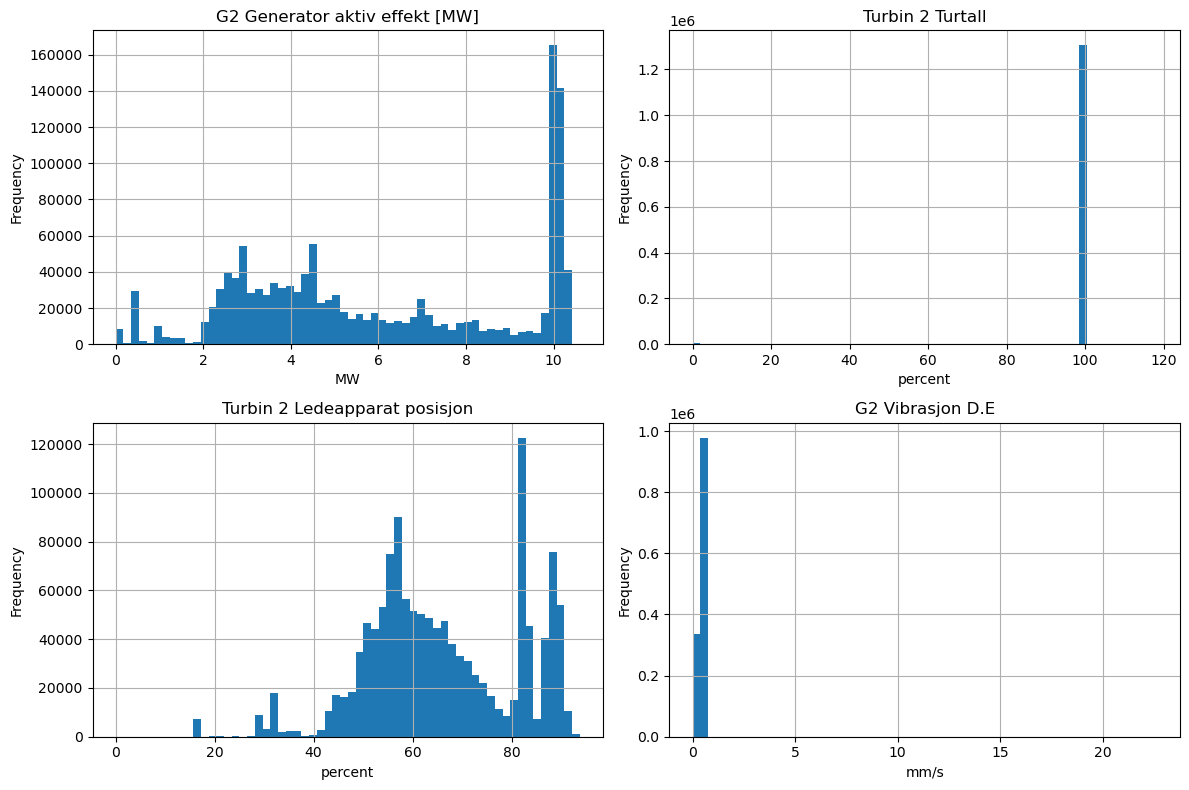

In [10]:
important_signals = [
    "power",
    "speed",
    "guide_vane_position",
    "vibration"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, signal_name in zip(axes, important_signals):
    row = dfs[dfs["name"] == signal_name].iloc[0]

    df = row["signal_df"]
    unit = row["unit"]
    unit_clean = str(unit).split(":")[-1] if pd.notna(unit) else ""

    ax.hist(df["signal"].dropna(), bins=60)
    ax.set_title(signal_name)
    ax.set_xlabel(unit_clean)
    ax.set_ylabel("Frequency")
    ax.grid(True)

plt.tight_layout()
plt.savefig("important_signal_histograms.png", dpi=300)
plt.show()

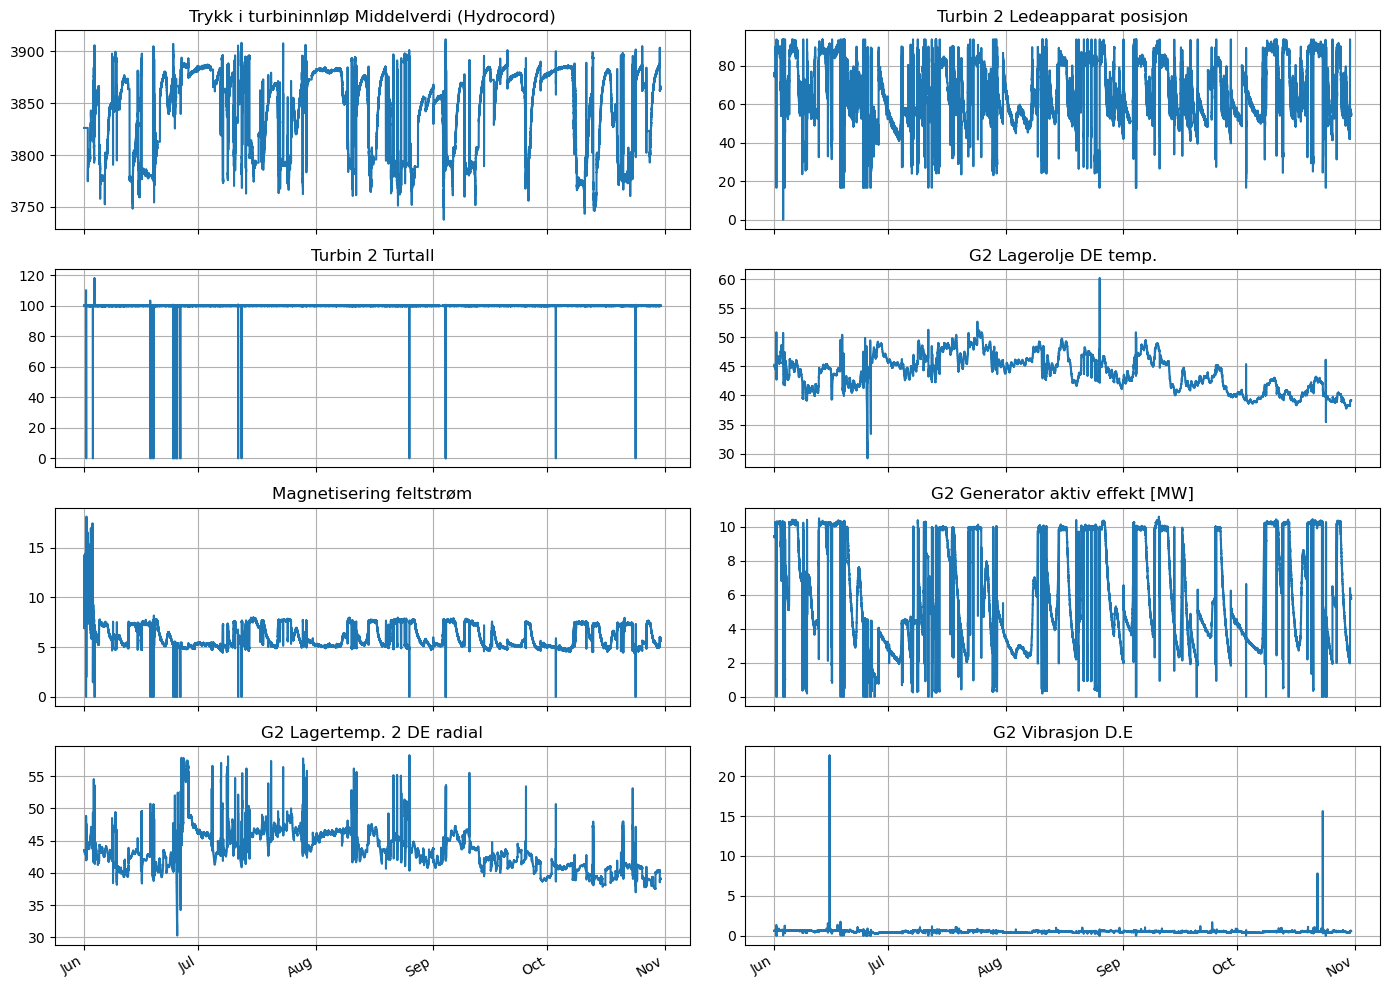

In [67]:
num_plots = len(dfs)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(14, 2.5 * num_rows)
)

axes = axes.flatten()

for i in range(num_plots):
    name = dfs.loc[i, "name"]
    df = dfs.loc[i, "signal_df"]

    axes[i].plot(df["Datetime"], df["signal"])
    axes[i].set_title(name)
    axes[i].grid(True)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

for ax in axes[num_plots:]:
    ax.remove()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [4]:
speed_name = "speed"
power_name = "power"

speed = dfs.loc[dfs["name"] == speed_name, "signal_df"].iloc[0]
power = dfs.loc[dfs["name"] == power_name, "signal_df"].iloc[0]

operating_periods = extract_operating_periods(
    speed_df=speed,
    power_df=power,
    speed_threshold=90,
    power_threshold=0.5,
    min_samples=30
)

print("Number of operating periods:", len(operating_periods))
operating_periods.head()


Number of operating periods: 59


,start_time,end_time,n_samples
0,2024-06-01 00:00:00,2024-06-01 12:36:50,4542
1,2024-06-01 13:55:20,2024-06-03 07:38:30,15020
2,2024-06-03 08:01:10,2024-06-03 12:49:10,1729
3,2024-06-03 13:12:20,2024-06-03 17:54:30,1694
4,2024-06-03 19:08:40,2024-06-08 08:57:00,39531


In [5]:
pelt_times = find_pelt_change_points(
    ref_df=power,
    operating_periods=operating_periods.head(6),
    min_size=3
)

print("PELT breakpoints:", len(pelt_times))

PELT breakpoints: 60


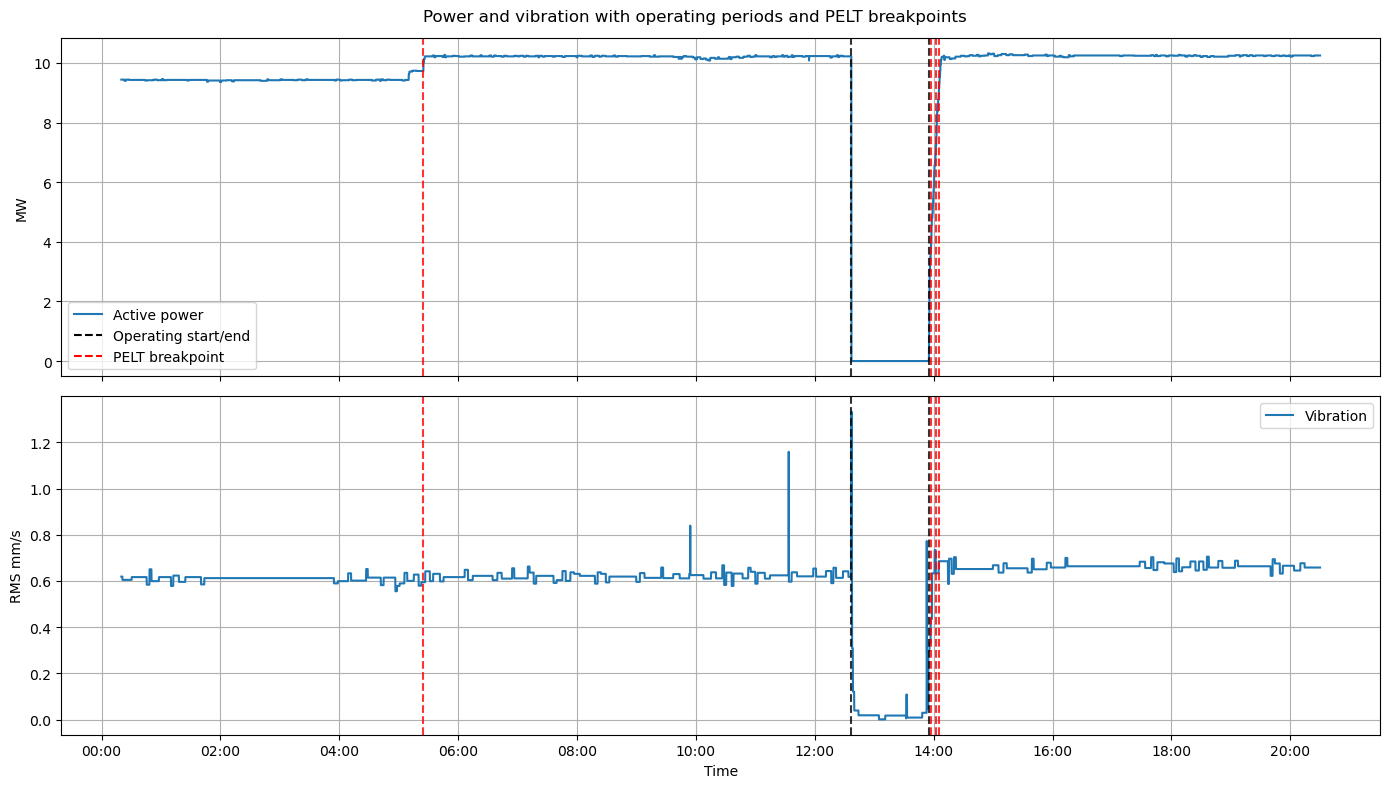

In [6]:
power_name = "power"
vib_name = "vibration"

power = dfs.loc[dfs["name"] == power_name, "signal_df"].iloc[0]
vib = dfs.loc[dfs["name"] == vib_name, "signal_df"].iloc[0]

plot_start = pd.Timestamp("2024-06-01 00:20:00")
plot_end = plot_start + pd.Timedelta(hours=20, minutes=10)

power_plot = power[power["Datetime"].between(plot_start, plot_end)]
vib_plot = vib[vib["Datetime"].between(plot_start, plot_end)]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle("Power and vibration with operating periods and PELT breakpoints")

axes[0].plot(power_plot["Datetime"], power_plot["signal"], label="Active power")
axes[0].set_ylabel("MW")
axes[0].grid(True)

axes[1].plot(vib_plot["Datetime"], vib_plot["signal"], label="Vibration")
axes[1].set_ylabel("RMS mm/s")
axes[1].set_xlabel("Time")
axes[1].grid(True)

# Operating period start/end
for _, period in operating_periods.iterrows():
    for t in [period["start_time"], period["end_time"]]:
        if plot_start <= t <= plot_end:
            axes[0].axvline(t, color="black", linestyle="--", alpha=0.8)
            axes[1].axvline(t, color="black", linestyle="--", alpha=0.8)

# PELT breakpoints
for t in pelt_times:
    if plot_start <= t <= plot_end:
        axes[0].axvline(t, color="red", linestyle="--", alpha=0.8)
        axes[1].axvline(t, color="red", linestyle="--", alpha=0.8)

# Legend
axes[0].plot([], [], color="black", linestyle="--", label="Operating start/end")
axes[0].plot([], [], color="red", linestyle="--", label="PELT breakpoint")

axes[0].legend()
axes[1].legend()

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.savefig("power_vibration_pelt_breakpoints.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
windows = make_window_features(
    ref_df=power,
    operating_periods=operating_periods,
    window_size=6,
    n_periods=6
)

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

X = windows[["mean_power", "std_power"]]

X_scaled = StandardScaler().fit_transform(X)

dbscan = DBSCAN(
    eps=0.09,
    min_samples=5
)

windows["cluster"] = dbscan.fit_predict(X_scaled)

In [39]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

results = []

for eps in np.arange(0.05, 0.401, 0.02):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)

    n_clusters = len(set(labels) - {-1})
    noise_fraction = (labels == -1).mean()

    results.append({
        "eps": round(eps, 2),
        "n_clusters": n_clusters,
        "noise_percent": noise_fraction * 100
    })

pd.DataFrame(results)

,eps,n_clusters,noise_percent
0,0.05,52,3.592446
1,0.07,15,2.134387
2,0.09,5,1.519543
3,0.11,6,1.264822
4,0.13,6,1.141853
5,0.15,6,1.036451
6,0.17,7,0.931050
7,0.19,4,0.887132
8,0.21,4,0.834431
9,0.23,3,0.825648


In [50]:
summary = (
    windows
    .groupby("cluster")
    .agg(
        n_windows=("cluster", "size"),
        mean_power=("mean_power", "mean"),
        mean_std_power=("std_power", "mean"),
        min_power=("mean_power", "min"),
        max_power=("mean_power", "max")
    )
)

summary

,n_windows,mean_power,mean_std_power,min_power,max_power
cluster,,,,,
-1,101,5.749587,0.300487,0.536667,10.205000
0,10896,8.798152,0.004294,5.100000,10.410000
1,269,3.951883,0.001299,3.690000,4.060000
2,114,0.872939,0.003263,0.690000,1.080000
3,5,5.576667,0.058729,5.290000,5.833333


In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

# Fixed cluster labels and fixed color mapping
clusters = sorted(windows["cluster"].unique())

cmap = plt.get_cmap("tab20")
norm = mcolors.BoundaryNorm(
    boundaries=[c - 0.5 for c in clusters] + [clusters[-1] + 0.5],
    ncolors=cmap.N
)

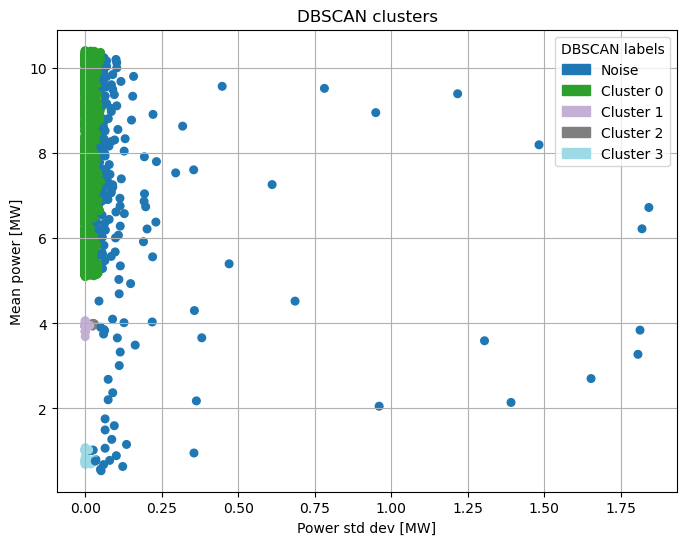

In [54]:
plt.figure(figsize=(8, 6))

plt.scatter(
    windows["std_power"],
    windows["mean_power"],
    c=windows["cluster"],
    cmap=cmap,
    norm=norm,
    s=30
)

handles = []
for cluster in clusters:
    color = cmap(norm(cluster))
    label = "Noise" if cluster == -1 else f"Cluster {cluster}"
    handles.append(mpatches.Patch(color=color, label=label))

plt.legend(handles=handles, title="DBSCAN labels")

plt.xlabel("Power std dev [MW]")
plt.ylabel("Mean power [MW]")
plt.title("DBSCAN clusters")
plt.grid(True)
plt.show()

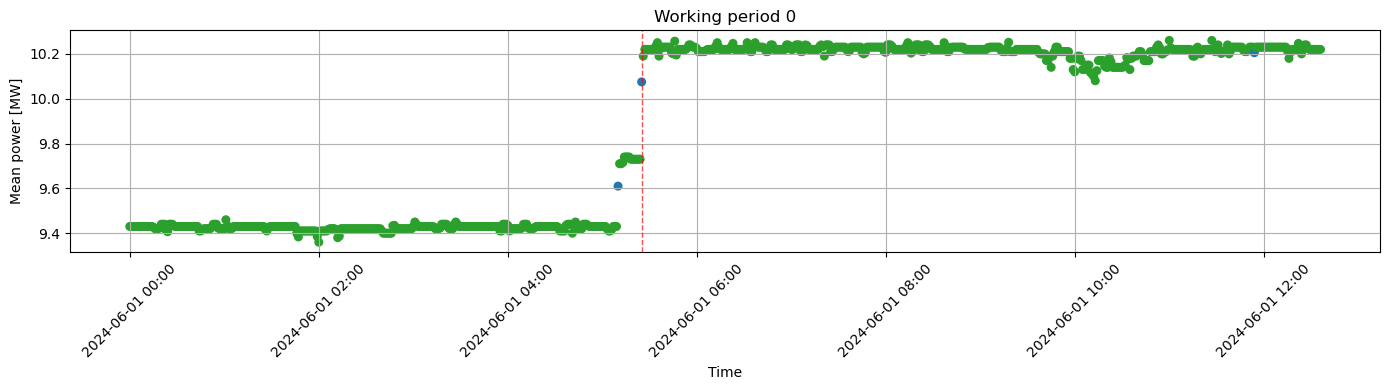

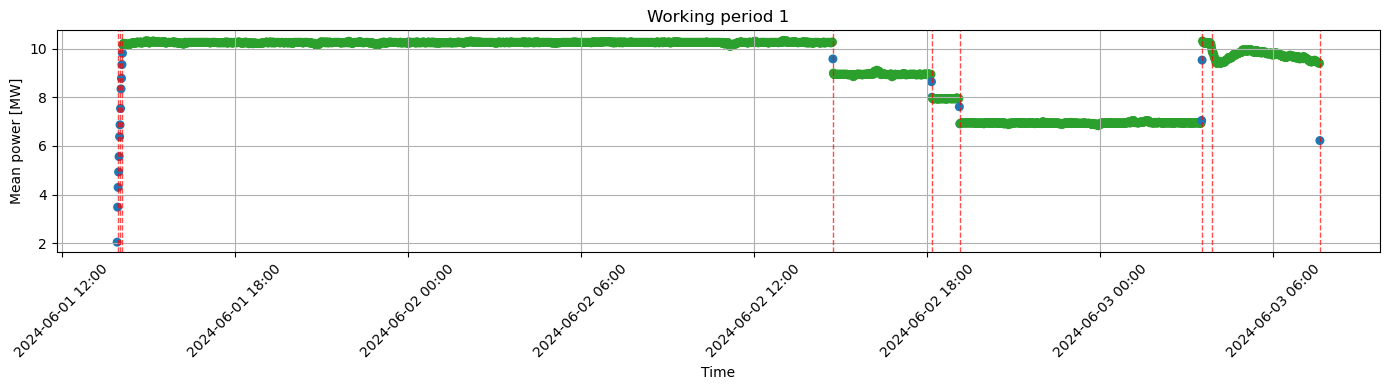

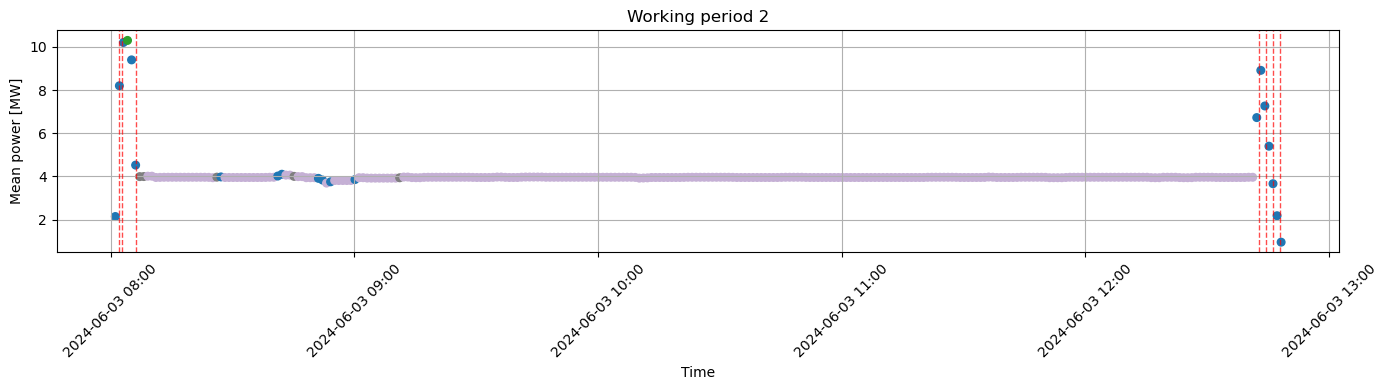

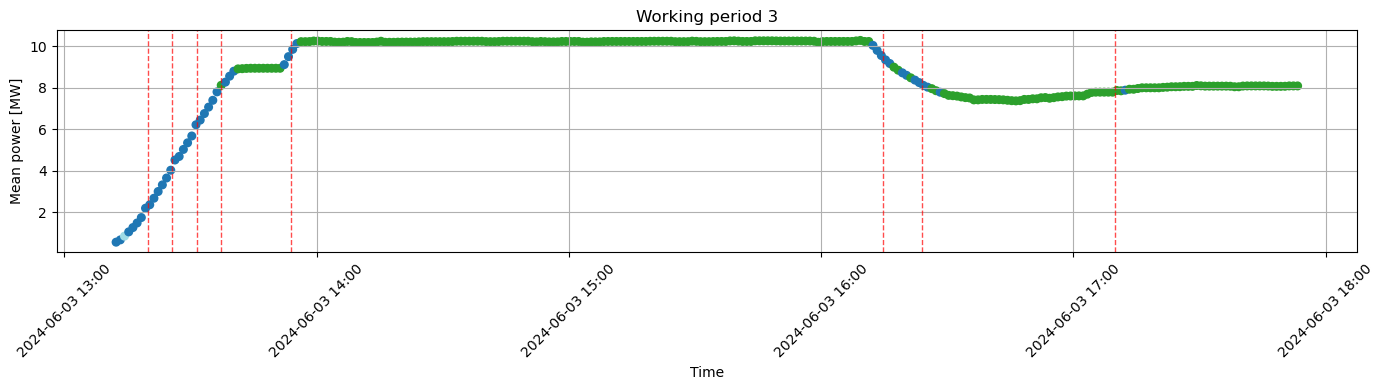

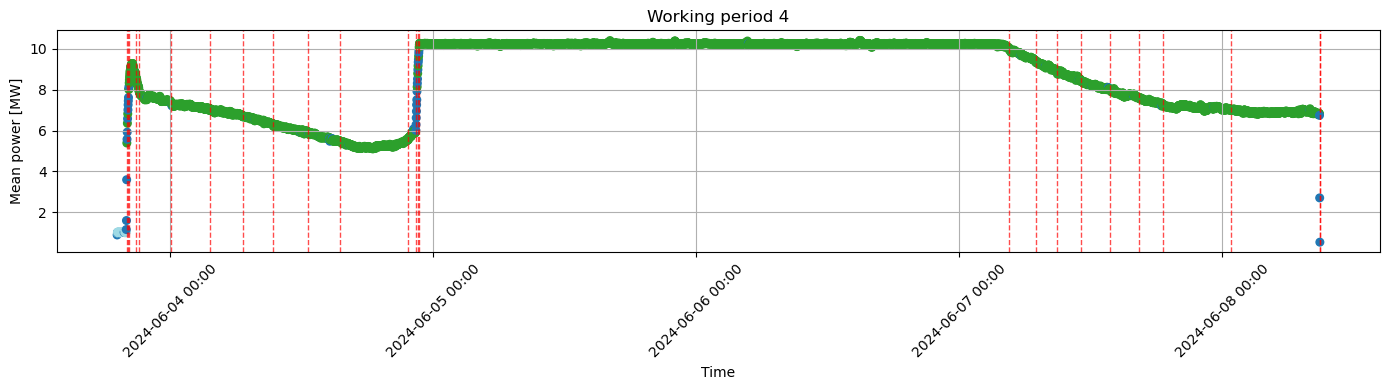

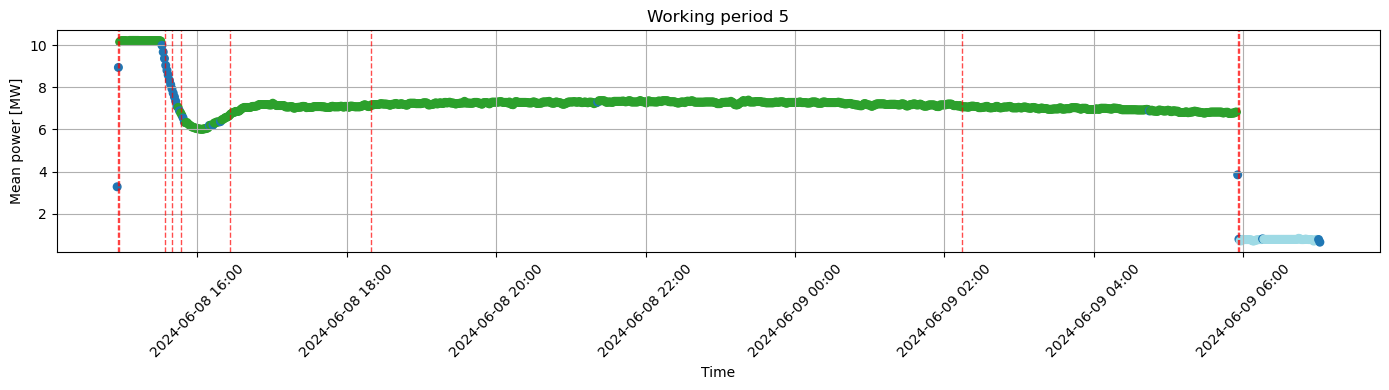

In [55]:
for wp in sorted(windows["working_period"].unique()):
    temp = windows[windows["working_period"] == wp]

    plt.figure(figsize=(14, 4))

    plt.scatter(
        temp["start_time"],
        temp["mean_power"],
        c=temp["cluster"],
        cmap=cmap,
        norm=norm,
        s=30
    )

    # Add PELT change points inside this working period
    start = temp["start_time"].min()
    end = temp["end_time"].max()

    for t in pelt_times:
        if start <= t <= end:
            plt.axvline(
                t,
                color="red",
                linestyle="--",
                linewidth=1,
                alpha=0.7
            )

    plt.xlabel("Time")
    plt.ylabel("Mean power [MW]")
    plt.title(f"Working period {wp}")
    plt.grid(True)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import pearsonr
import dcor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vib_name = "vibration"

# Get vibration signal
vib = dfs.loc[dfs["name"] == vib_name, "signal_df"].iloc[0]

# Keep only working timestamps
working_times = operation_df.loc[operation_df["is_working"], ["Datetime"]]

# Vibration during working periods
vib_working = working_times.merge(vib, on="Datetime")
vib_working = vib_working.rename(columns={"signal": vib_name})

results = []

for i in range(len(dfs)):
    name = dfs.loc[i, "name"]

    if name == vib_name:
        continue

    signal_df = dfs.loc[i, "signal_df"]

    data = vib_working.merge(signal_df, on="Datetime")
    data = data.rename(columns={"signal": name})
    data = data.dropna()

    if len(data) < 2:
        continue

    results.append({
        "Signal": name,
        "Pearson": pearsonr(data[vib_name], data[name])[0],
        "Distance": dcor.distance_correlation(
            data[vib_name].to_numpy(),
            data[name].to_numpy()
        )
    })

corr_df = pd.DataFrame(results).sort_values("Distance", ascending=False)

# Bar plot
x = np.arange(len(corr_df))
w = 0.35

plt.figure(figsize=(16, 7))

plt.bar(x - w/2, corr_df["Distance"], width=w, label="Distance correlation")
plt.bar(x + w/2, corr_df["Pearson"], width=w, label="Pearson correlation")

plt.xticks(x, corr_df["Signal"], rotation=75, ha="right")
plt.ylabel("Correlation coefficient")
plt.title("Correlation with vibration during operating periods")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()

plt.savefig("correlation_with_vibration_operating_periods.png", dpi=300, bbox_inches="tight")

plt.show()

corr_df